# Assignment 7: Build and Evaluate Unsupervised Learning Models

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80)

## Conceptual Question 1

The K-means objective can be written as the sum of within-cluster squared distances.  The identity in the text shows that this is equivalent to measuring pairwise distances within each cluster up to a constant.  The algorithm decreases the objective at each iteration because the assignment step chooses the closest centroid for each observation, and the update step sets each centroid to the mean of its assigned observations.  Each step cannot increase the within-cluster sum of squares, so the procedure moves toward a local optimum.

## Applied Question 9: USArrests Hierarchical Clustering

The USArrests exercise shows why scaling matters in unsupervised learning.  Without scaling, variables with larger units dominate Euclidean distance.  After scaling, each variable contributes on a comparable standard-deviation scale.

,raw_cluster,scaled_cluster
rownames,,
Delaware,1,1
Arkansas,2,1
Massachusetts,2,1
Missouri,2,1
New Jersey,2,1
Oklahoma,2,1
Oregon,2,1
Rhode Island,2,1
Virginia,2,1


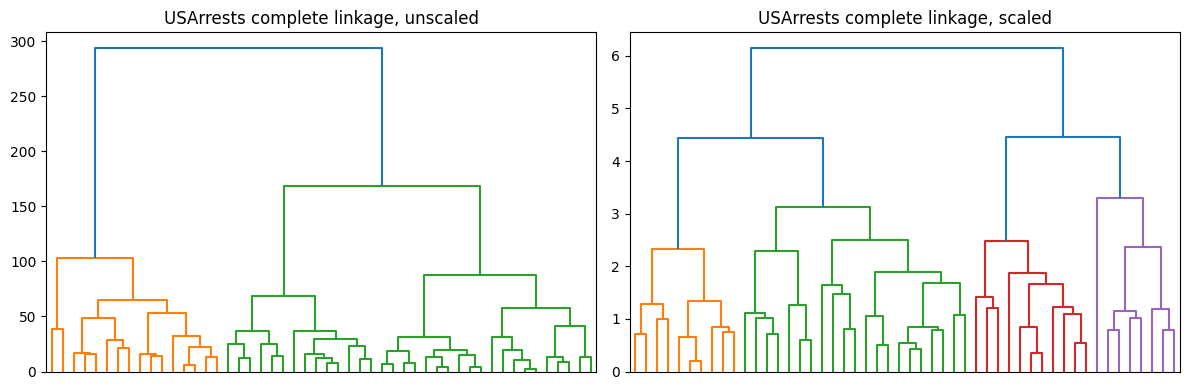

In [2]:
import statsmodels.api as sm
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.preprocessing import StandardScaler

usarrests = sm.datasets.get_rdataset("USArrests", "datasets").data
Z_raw = linkage(usarrests, method="complete", metric="euclidean")
raw_clusters = pd.Series(fcluster(Z_raw, 3, criterion="maxclust"), index=usarrests.index, name="raw_cluster")
scaled = StandardScaler().fit_transform(usarrests)
Z_scaled = linkage(scaled, method="complete", metric="euclidean")
scaled_clusters = pd.Series(fcluster(Z_scaled, 3, criterion="maxclust"), index=usarrests.index, name="scaled_cluster")
display(pd.concat([raw_clusters, scaled_clusters], axis=1).sort_values(["scaled_cluster", "raw_cluster"]).head(20))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dendrogram(Z_raw, labels=usarrests.index, leaf_rotation=90, no_labels=True, ax=axes[0])
axes[0].set_title("USArrests complete linkage, unscaled")
dendrogram(Z_scaled, labels=usarrests.index, leaf_rotation=90, no_labels=True, ax=axes[1])
axes[1].set_title("USArrests complete linkage, scaled")
plt.tight_layout()

## Wine PCA and Clustering

The Wine clustering data set is scaled before PCA, K-means, and hierarchical clustering.  Scaling is required because the chemical measurements are on different units and would otherwise distort distance-based methods.

,missing_count
Alcohol,0
Malic_Acid,0
Ash,0
Ash_Alcanity,0
Magnesium,0
Total_Phenols,0
Flavanoids,0
Nonflavanoid_Phenols,0
Proanthocyanins,0
Color_Intensity,0


Components needed for 80% variance: 5


,component,cumulative_variance
0,1,0.361988
1,2,0.554063
2,3,0.665300
3,4,0.735990
4,5,0.801623
5,6,0.850981
6,7,0.893368
7,8,0.920175
8,9,0.942397
9,10,0.961697


,PC1,PC2,PC3,PC4
Alcohol,0.144329,0.483652,-0.207383,-0.017856
Malic_Acid,-0.245188,0.224931,0.089013,0.536890
Ash,-0.002051,0.316069,0.626224,-0.214176
Ash_Alcanity,-0.239320,-0.010591,0.612080,0.060859
Magnesium,0.141992,0.299634,0.130757,-0.351797
Total_Phenols,0.394661,0.065040,0.146179,0.198068
Flavanoids,0.422934,-0.003360,0.150682,0.152295
Nonflavanoid_Phenols,-0.298533,0.028779,0.170368,-0.203301
Proanthocyanins,0.313429,0.039302,0.149454,0.399057
Color_Intensity,-0.088617,0.529996,-0.137306,0.065926


,k,inertia,silhouette
0,2,1201.157500,0.323917
1,3,825.020838,0.369076
2,4,723.935749,0.325619
3,5,661.429070,0.307802
4,6,605.376056,0.272779
5,7,558.113912,0.275598


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
kmeans_cluster,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


hierarchical_cluster
0    55
1    58
2    65
Name: count, dtype: int64

hierarchical,0,1,2
kmeans,,,
0,6,56,3
1,49,2,0
2,0,0,62


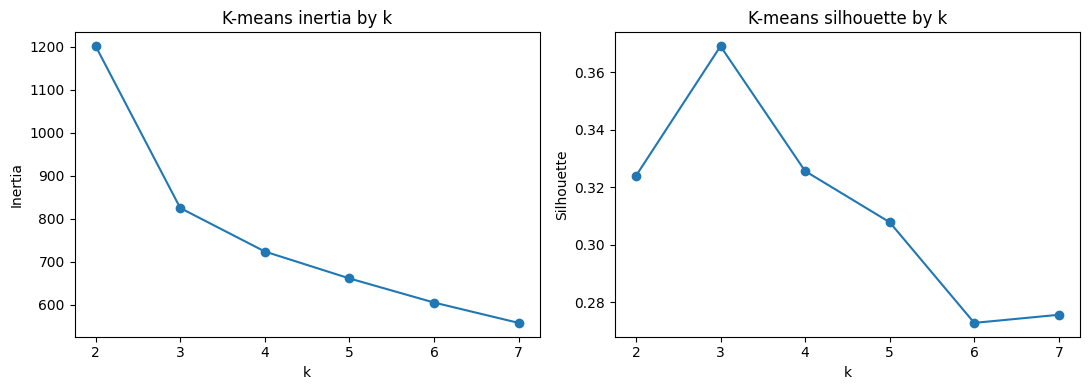

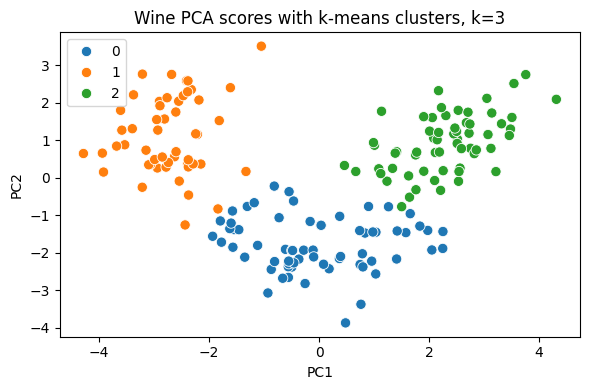

In [3]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

wine = pd.read_csv(KAGGLE / "wine-dataset-for-clustering" / "wine-clustering.csv")
display(wine.isna().sum().rename("missing_count").to_frame())
X_scaled = StandardScaler().fit_transform(wine)
pca_full = PCA().fit(X_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.argmax(cumulative >= .80) + 1)
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
scores = pca.fit_transform(X_scaled)
print("Components needed for 80% variance:", n_components)
display(pd.DataFrame({"component": range(1, len(cumulative)+1), "cumulative_variance": cumulative}).head(10))
loadings = pd.DataFrame(
    pca.components_.T,
    index=wine.columns,
    columns=[f"PC{i}" for i in range(1, n_components + 1)],
)
display(loadings.iloc[:, :min(4, n_components)])
rows = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit(scores)
    rows.append({"k": k, "inertia": km.inertia_, "silhouette": silhouette_score(scores, km.labels_)})
cluster_eval = pd.DataFrame(rows)
display(cluster_eval)
best_k = int(cluster_eval.sort_values("silhouette", ascending=False).iloc[0]["k"])
km_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20).fit(scores)
wine_profiles = wine.assign(kmeans_cluster=km_best.labels_).groupby("kmeans_cluster").mean()
display(wine_profiles)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(cluster_eval["k"], cluster_eval["inertia"], marker="o")
axes[0].set_title("K-means inertia by k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[1].plot(cluster_eval["k"], cluster_eval["silhouette"], marker="o")
axes[1].set_title("K-means silhouette by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.figure(figsize=(6, 4))
sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=km_best.labels_, palette="tab10", s=55)
plt.title(f"Wine PCA scores with k-means clusters, k={best_k}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
hc = AgglomerativeClustering(n_clusters=3, linkage="ward").fit(scores)
display(pd.Series(hc.labels_, name="hierarchical_cluster").value_counts().sort_index())
display(pd.crosstab(pd.Series(km_best.labels_, name="kmeans"), pd.Series(hc.labels_, name="hierarchical")))

In [4]:
display(pd.DataFrame({
    "evidence": ["Public GitHub repository", "Notebook path in repository"],
    "value": [
        "https://github.com/maldo81/dds-8555-predictive-analysis",
        "Week 7/Assignment 7/MaldonadoJDDS8555-7.ipynb",
    ],
}))

,evidence,value
0,Public GitHub repository,https://github.com/maldo81/dds-8555-predictive...
1,Notebook path in repository,Week 7/Assignment 7/MaldonadoJDDS8555-7.ipynb


## Interpretation

PCA retained at least 80% of the variance with fewer components than the original feature set, which makes the clustering task easier to visualize and less redundant (Jolliffe, 2002).  K-means was evaluated across several k values using both inertia and silhouette rather than assuming a single cluster count.  The cluster-profile table translates the clusters back into the original wine chemistry variables, which is necessary because PCA scores alone are not substantively meaningful.  Hierarchical clustering gave a second view of the grouping structure and helped test whether the K-means result was a method artifact.  The assumptions are practical rather than parametric: variables must be scaled, missingness must be checked, Euclidean distance must be meaningful for standardized chemical measures, and clusters should be interpreted as exploratory structure rather than verified wine classes (Cortez et al., 2009).

## References

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009).  Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems, 47*(4), 547-553. https://doi.org/10.1016/j.dss.2009.05.016

Jolliffe, I.  T. (2002). *Principal component analysis* (2nd ed.).  Springer. https://doi.org/10.1007/b98835

MacQueen, J. (1967).  Some methods for classification and analysis of multivariate observations.  In *Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability* (Vol.  1, pp.  281-297).

Ward, J.  H. (1963).  Hierarchical grouping to optimize an objective function. *Journal of the American Statistical Association, 58*(301), 236-244. https://doi.org/10.1080/01621459.1963.10500845